In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/creditcard.csv')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
print("All imports done!", tf.__version__)

All imports done! 2.19.0


In [ ]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nNull values:")
print(df.isnull().sum().sum(), "null values found")
print("\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud %: {df['Class'].mean()*100:.2f}%")

Shape: (17918, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0



Null values:
26 null values found

Class Distribution:
Class
0.0    17836
1.0       81
Name: count, dtype: int64

Fraud %: 0.45%


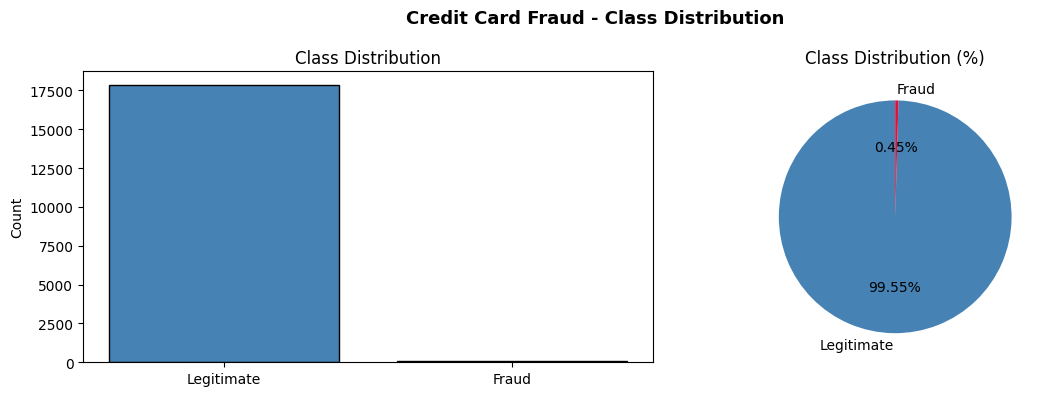

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
axes[0].bar(['Legitimate', 'Fraud'],
            [df['Class'].value_counts()[0], df['Class'].value_counts()[1]],
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie([df['Class'].value_counts()[0], df['Class'].value_counts()[1]],
            labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%',
            colors=['steelblue', 'crimson'],
            startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Credit Card Fraud - Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

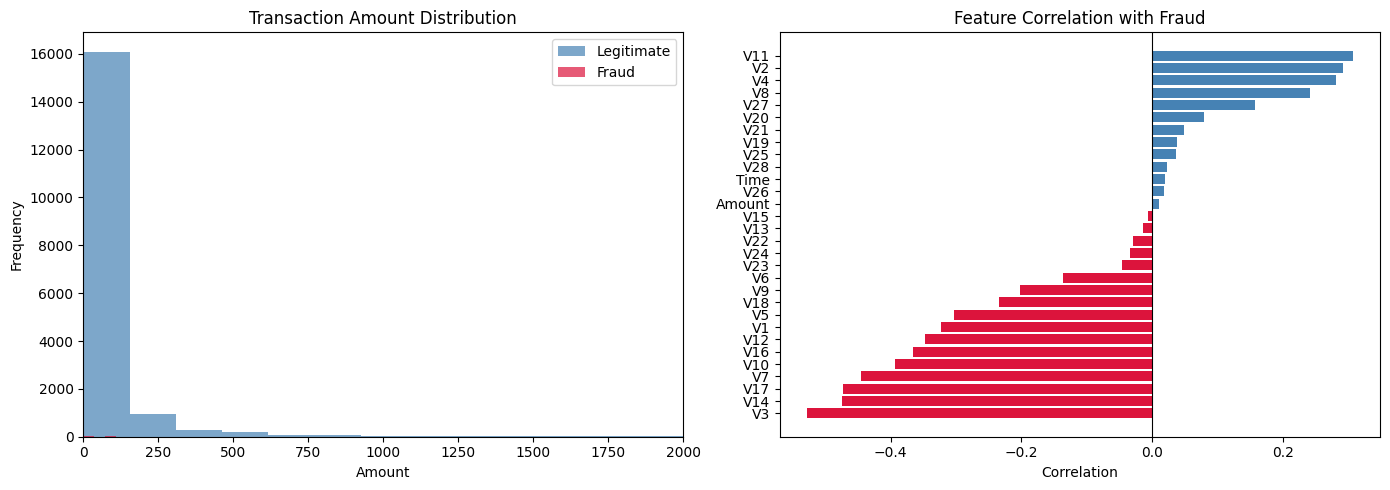

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution by class
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7,
             color='steelblue', label='Legitimate')
axes[0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7,
             color='crimson', label='Fraud')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 2000)
axes[0].legend()

# Correlation of V features with Class
corr = df.corr()['Class'].drop('Class').sort_values()
colors = ['crimson' if x < 0 else 'steelblue' for x in corr]
axes[1].barh(corr.index, corr.values, color=colors)
axes[1].set_title('Feature Correlation with Fraud')
axes[1].set_xlabel('Correlation')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

In [ ]:
# Drop nulls
df.dropna(inplace=True)
print("After dropping nulls:", df.shape)

# Scale Amount and Time
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['Time']   = scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Split features and target
X = df.drop('Class', axis=1).values
y = df['Class'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"Train size after SMOTE : {X_train.shape[0]}")
print(f"Class 0: {sum(y_train==0)}  |  Class 1: {sum(y_train==1)}")
print(f"Test size : {X_test.shape[0]}")

# Reshape for CNN → (samples, features, 1)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f"\nCNN input shape: {X_train.shape}")

After dropping nulls: (17917, 31)
Train size after SMOTE : 28536
Class 0: 14268  |  Class 1: 14268
Test size : 3584

CNN input shape: (28536, 30, 1)


In [ ]:
model = Sequential([
    # Block 1
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(30,1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    # Block 2
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    # Block 3
    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.3),

    # Classifier
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 7, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       229,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,945 (1.35 MB)

 Trainable params: 354,049 (1.35 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Recompile with fixed AUC metric name
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc', curve='ROC')]
)

# Fix: monitor val_loss instead
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete!")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 32s 153ms/step - accuracy: 0.9948 - auc: 0.9990 - loss: 0.0223 - precision: 0.9920 - recall: 0.9953 - val_accuracy: 0.9516 - val_auc: 0.0000e+00 - val_loss: 0.0867 - val_precision: 1.0000 - val_recall: 0.9516
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.9969 - auc: 0.9995 - loss: 0.0124 - precision: 0.9951 - recall: 0.9975 - val_accuracy: 0.9974 - val_auc: 0.0000e+00 - val_loss: 0.0156 - val_precision: 1.0000 - val_recall: 0.9974
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.9976 - auc: 0.9997 - loss: 0.0097 - precision: 0.9953 - recall: 0.9988 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 6.6860e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.9981 - auc: 0.9995 - loss: 0.0095 - precision: 0.9961 - recall: 0.9993 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 8.8118e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch

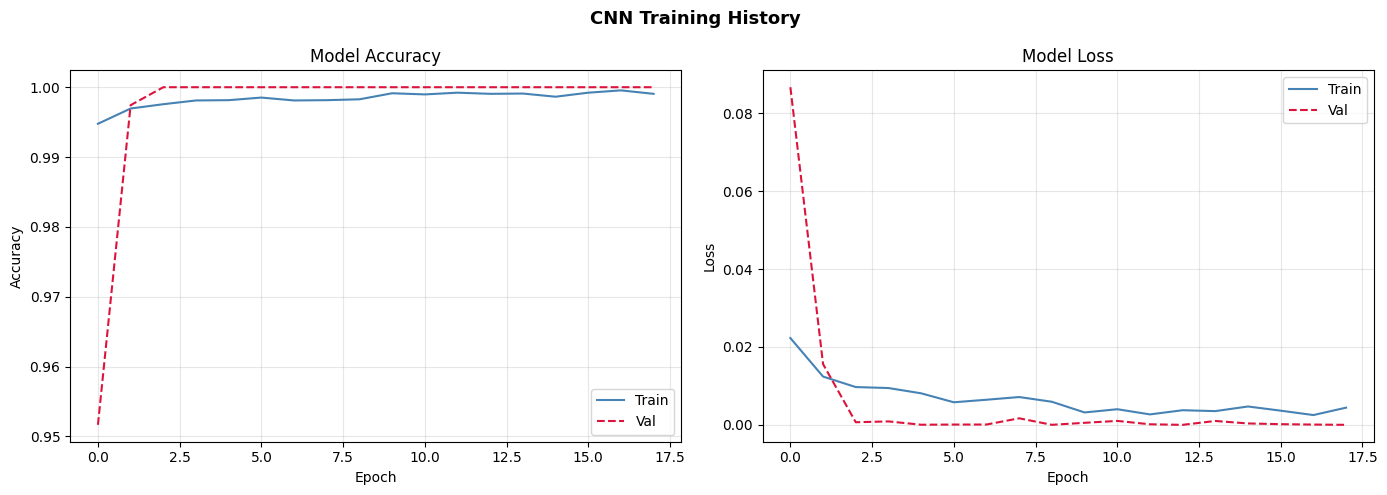

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='crimson', linestyle='--')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   color='crimson', linestyle='--')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('CNN Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("="*40)
print("      FINAL TEST RESULTS")
print("="*40)
print(f"Test Samples   : {len(y_test)}")
print(f"Accuracy       : {acc*100:.2f}%")
print(f"Precision      : {prec:.4f}")
print(f"Recall         : {rec:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC-AUC        : {roc_auc:.4f}")
print("="*40)

      FINAL TEST RESULTS
Test Samples   : 3584
Accuracy       : 99.78%
Precision      : 0.6667
Recall         : 1.0000
F1 Score       : 0.8000
ROC-AUC        : 0.9998


112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      3568
       Fraud       0.67      1.00      0.80        16

    accuracy                           1.00      3584
   macro avg       0.83      1.00      0.90      3584
weighted avg       1.00      1.00      1.00      3584



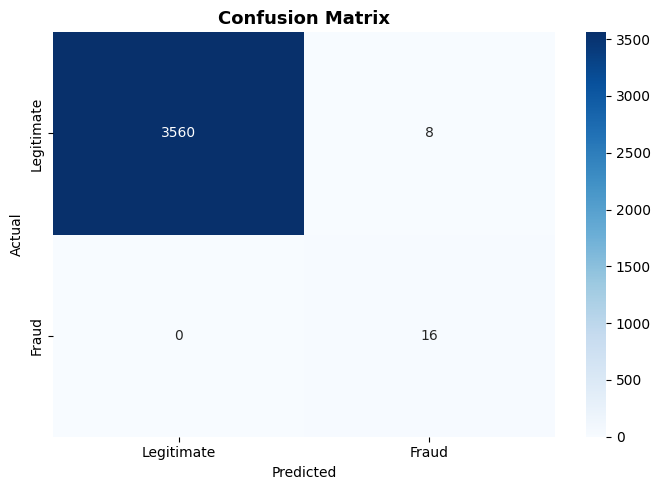

True  Negatives : 3560
False Positives : 8
False Negatives : 0
True  Positives : 16


In [ ]:
# Predictions
y_pred_prob = model.predict(X_test).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

# Classification Report
print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True  Positives : {tp}")


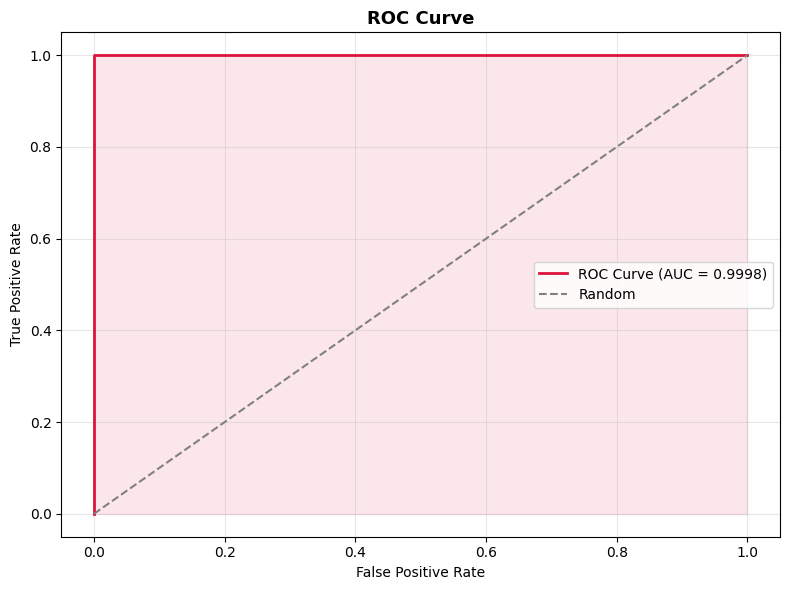

ROC-AUC Score: 0.9998
Model saved!


In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='crimson')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

# Save model
model.save('fraud_cnn_model.h5')
print("Model saved!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save model in both formats
model.save('/content/drive/MyDrive/fraud_cnn_model.h5')
model.save('/content/drive/MyDrive/fraud_cnn_model.keras')

print("Model saved to Google Drive!")

Mounted at /content/drive
Model saved to Google Drive!
